In [1]:
# GOAL IS TO DO ANALYSIS ON AIRLINE AGENCY'S DATABASE AND TO GIVE EFFECTIVE SOLITIONS FOR EFFICIENCY 

In [2]:
# IMPORTING LIBRARIES

In [34]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

In [4]:
import sqlite3

conn = sqlite3.connect("travel.sqlite")

In [5]:
import os

print(os.path.abspath("travel.sqlite"))

C:\Users\Yash\travel.sqlite


In [6]:
connection = sqlite3.connect(r"C:\Users\Yash\travel.sqlite")
cursor = connection.cursor()

In [7]:
cursor.execute("""SELECT name FROM sqlite_master WHERE type = 'table';""")
print(cursor.fetchall())  

[('aircrafts_data',), ('airports_data',), ('boarding_passes',), ('bookings',), ('flights',), ('seats',), ('ticket_flights',), ('tickets',)]


In [8]:
import os

print(os.path.abspath("travel.sqlite"))
print(os.path.getsize("travel.sqlite"))

C:\Users\Yash\travel.sqlite
109531136


In [9]:
# DATA EXPLORATION
# LETS SEE THE DATA IN EACH TABLES BY USING PANDAS SQL QUERIES

In [10]:
aircrafts_data = pd.read_sql_query(" select * from aircrafts_data" , connection)
aircrafts_data

,aircraft_code,model,range
0,773,"{""en"": ""Boeing 777-300"", ""ru"": ""Боинг 777-300""}",11100
1,763,"{""en"": ""Boeing 767-300"", ""ru"": ""Боинг 767-300""}",7900
2,SU9,"{""en"": ""Sukhoi Superjet-100"", ""ru"": ""Сухой Суп...",3000
3,320,"{""en"": ""Airbus A320-200"", ""ru"": ""Аэробус A320-...",5700
4,321,"{""en"": ""Airbus A321-200"", ""ru"": ""Аэробус A321-...",5600
5,319,"{""en"": ""Airbus A319-100"", ""ru"": ""Аэробус A319-...",6700
6,733,"{""en"": ""Boeing 737-300"", ""ru"": ""Боинг 737-300""}",4200
7,CN1,"{""en"": ""Cessna 208 Caravan"", ""ru"": ""Сессна 208...",1200
8,CR2,"{""en"": ""Bombardier CRJ-200"", ""ru"": ""Бомбардье ...",2700


In [11]:
airports_data = pd.read_sql_query(" select * from airports_data" , connection)
airports_data

,airport_code,airport_name,city,coordinates,timezone
0,YKS,"{""en"": ""Yakutsk Airport"", ""ru"": ""Якутск""}","{""en"": ""Yakutsk"", ""ru"": ""Якутск""}","(129.77099609375,62.0932998657226562)",Asia/Yakutsk
1,MJZ,"{""en"": ""Mirny Airport"", ""ru"": ""Мирный""}","{""en"": ""Mirnyj"", ""ru"": ""Мирный""}","(114.03900146484375,62.534698486328125)",Asia/Yakutsk
2,KHV,"{""en"": ""Khabarovsk-Novy Airport"", ""ru"": ""Хабар...","{""en"": ""Khabarovsk"", ""ru"": ""Хабаровск""}","(135.18800354004,48.5279998779300001)",Asia/Vladivostok
3,PKC,"{""en"": ""Yelizovo Airport"", ""ru"": ""Елизово""}","{""en"": ""Petropavlovsk"", ""ru"": ""Петропавловск-К...","(158.453994750976562,53.1679000854492188)",Asia/Kamchatka
4,UUS,"{""en"": ""Yuzhno-Sakhalinsk Airport"", ""ru"": ""Хом...","{""en"": ""Yuzhno-Sakhalinsk"", ""ru"": ""Южно-Сахали...","(142.718002319335938,46.8886985778808594)",Asia/Sakhalin
...,...,...,...,...,...
99,MMK,"{""en"": ""Murmansk Airport"", ""ru"": ""Мурманск""}","{""en"": ""Murmansk"", ""ru"": ""Мурманск""}","(32.7508010864257812,68.7817001342773438)",Europe/Moscow
100,ABA,"{""en"": ""Abakan Airport"", ""ru"": ""Абакан""}","{""en"": ""Abakan"", ""ru"": ""Абакан""}","(91.3850021362304688,53.7400016784667969)",Asia/Krasnoyarsk
101,BAX,"{""en"": ""Barnaul Airport"", ""ru"": ""Барнаул""}","{""en"": ""Barnaul"", ""ru"": ""Барнаул""}","(83.5384979248046875,53.363800048828125)",Asia/Krasnoyarsk
102,AAQ,"{""en"": ""Anapa Vityazevo Airport"", ""ru"": ""Витяз...","{""en"": ""Anapa"", ""ru"": ""Анапа""}","(37.3473014831539984,45.002101898192997)",Europe/Moscow


In [12]:
boarding_passes = pd.read_sql_query(" select * from boarding_passes" , connection)
boarding_passes

,ticket_no,flight_id,boarding_no,seat_no
0,0005435212351,30625,1,2D
1,0005435212386,30625,2,3G
2,0005435212381,30625,3,4H
3,0005432211370,30625,4,5D
4,0005435212357,30625,5,11A
...,...,...,...,...
579681,0005434302871,19945,85,20F
579682,0005432892791,19945,86,21C
579683,0005434302869,19945,87,20E
579684,0005432802476,19945,88,21F


In [13]:
bookings = pd.read_sql_query(" select * from bookings" , connection)
bookings

,book_ref,book_date,total_amount
0,00000F,2017-07-05 03:12:00+03,265700
1,000012,2017-07-14 09:02:00+03,37900
2,000068,2017-08-15 14:27:00+03,18100
3,000181,2017-08-10 13:28:00+03,131800
4,0002D8,2017-08-07 21:40:00+03,23600
...,...,...,...
262783,FFFEF3,2017-07-17 07:23:00+03,56000
262784,FFFF2C,2017-08-08 05:55:00+03,10800
262785,FFFF43,2017-07-20 20:42:00+03,78500
262786,FFFFA8,2017-08-08 04:45:00+03,28800


In [14]:
flights = pd.read_sql_query(" select * from flights" , connection)
flights

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
0,1185,PG0134,2017-09-10 09:50:00+03,2017-09-10 14:55:00+03,DME,BTK,Scheduled,319,\N,\N
1,3979,PG0052,2017-08-25 14:50:00+03,2017-08-25 17:35:00+03,VKO,HMA,Scheduled,CR2,\N,\N
2,4739,PG0561,2017-09-05 12:30:00+03,2017-09-05 14:15:00+03,VKO,AER,Scheduled,763,\N,\N
3,5502,PG0529,2017-09-12 09:50:00+03,2017-09-12 11:20:00+03,SVO,UFA,Scheduled,763,\N,\N
4,6938,PG0461,2017-09-04 12:25:00+03,2017-09-04 13:20:00+03,SVO,ULV,Scheduled,SU9,\N,\N
...,...,...,...,...,...,...,...,...,...,...
33116,33117,PG0063,2017-08-02 19:25:00+03,2017-08-02 20:10:00+03,SKX,SVO,Arrived,CR2,2017-08-02 19:25:00+03,2017-08-02 20:10:00+03
33117,33118,PG0063,2017-07-28 19:25:00+03,2017-07-28 20:10:00+03,SKX,SVO,Arrived,CR2,2017-07-28 19:30:00+03,2017-07-28 20:15:00+03
33118,33119,PG0063,2017-09-08 19:25:00+03,2017-09-08 20:10:00+03,SKX,SVO,Scheduled,CR2,\N,\N
33119,33120,PG0063,2017-08-01 19:25:00+03,2017-08-01 20:10:00+03,SKX,SVO,Arrived,CR2,2017-08-01 19:26:00+03,2017-08-01 20:12:00+03


In [15]:
seats = pd.read_sql_query(" select * from seats" , connection)
seats

,aircraft_code,seat_no,fare_conditions
0,319,2A,Business
1,319,2C,Business
2,319,2D,Business
3,319,2F,Business
4,319,3A,Business
...,...,...,...
1334,773,48H,Economy
1335,773,48K,Economy
1336,773,49A,Economy
1337,773,49C,Economy


In [16]:
ticket_flights = pd.read_sql_query(" select * from ticket_flights" , connection)
ticket_flights

,ticket_no,flight_id,fare_conditions,amount
0,0005432159776,30625,Business,42100
1,0005435212351,30625,Business,42100
2,0005435212386,30625,Business,42100
3,0005435212381,30625,Business,42100
4,0005432211370,30625,Business,42100
...,...,...,...,...
1045721,0005435097522,32094,Economy,5200
1045722,0005435097521,32094,Economy,5200
1045723,0005435104384,32094,Economy,5200
1045724,0005435104352,32094,Economy,5200


In [17]:
tickets = pd.read_sql_query(" select * from tickets" , connection)
tickets

,ticket_no,book_ref,passenger_id
0,0005432000987,06B046,8149 604011
1,0005432000988,06B046,8499 420203
2,0005432000989,E170C3,1011 752484
3,0005432000990,E170C3,4849 400049
4,0005432000991,F313DD,6615 976589
...,...,...,...
366728,0005435999869,D730BA,0474 690760
366729,0005435999870,D730BA,6535 751108
366730,0005435999871,A1AD46,1596 156448
366731,0005435999872,7B6A53,9374 822707


In [18]:
## AS WE HAVE FETCHED ALL THE TABLES FROM DATA SO NOW LET'S SEE THE DATA TYPES OF ALL THE COLUMNS PRESENT IN THE DATA

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table';
""")

tables = [table[0] for table in cursor.fetchall()]

for table in tables:
    print(f"\n{'='*50}")
    print(f"Table: {table}")
    print(f"{'='*50}")

    cursor.execute(f"PRAGMA table_info({table});")

    schema = cursor.fetchall()

    for column in schema:
        print(f"{column[1]:25} {column[2]}")


Table: aircrafts_data
aircraft_code             character(3)
model                     jsonb
range                     INTEGER

Table: airports_data
airport_code              character(3)
airport_name              jsonb
city                      jsonb
coordinates               point
timezone                  TEXT

Table: boarding_passes
ticket_no                 character(13)
flight_id                 INTEGER
boarding_no               INTEGER
seat_no                   character varying(4)

Table: bookings
book_ref                  character(6)
book_date                 timestamp with time zone
total_amount              numeric(10,2)

Table: flights
flight_id                 INTEGER
flight_no                 character(6)
scheduled_departure       timestamp with time zone
scheduled_arrival         timestamp with time zone
departure_airport         character(3)
arrival_airport           character(3)
status                    character varying(20)
aircraft_code             character(3)
ac

In [19]:
## NOW CHECK MISSING VALUES FROM ALL THE TABLES AND COLUMNS 

for table in tables:
    print(f"\n {table}")

    cursor.execute(f"PRAGMA table_info({table});")
    columns = [col[1] for col in cursor.fetchall()]

    for column in columns:
        cursor.execute(f"""
        SELECT COUNT(*)
        FROM {table}
        WHERE {column} IS NULL
        """)

        missing = cursor.fetchone()[0]

        print(f"{column:<30} {missing}")


 aircrafts_data
aircraft_code                  0
model                          0
range                          0

 airports_data
airport_code                   0
airport_name                   0
city                           0
coordinates                    0
timezone                       0

 boarding_passes
ticket_no                      0
flight_id                      0
boarding_no                    0
seat_no                        0

 bookings
book_ref                       0
book_date                      0
total_amount                   0

 flights
flight_id                      0
flight_no                      0
scheduled_departure            0
scheduled_arrival              0
departure_airport              0
arrival_airport                0
status                         0
aircraft_code                  0
actual_departure               0
actual_arrival                 0

 seats
aircraft_code                  0
seat_no                        0
fare_conditions              

In [20]:
## SO THE DATA IS CLEANED AND HAS NO MISSING VALUES THAT MEANS WE DON'T NEED TO DO FURTHER DATA CLEANING

In [21]:
## DATA ANALYSIS
## so for that lets do some basic things --->

In [22]:
# 1. HOW MANY PLANES HAVE MORE THAN 100 SEATS ?
pd.read_sql_query("""SELECT aircraft_code, count(*) as num_seats from seats
                   group by aircraft_code having num_seats > 100""" , connection)

,aircraft_code,num_seats
0,319,116
1,320,140
2,321,170
3,733,130
4,763,222
5,773,402


In [23]:
# 2. HOW MANY NUMBERS OF TICKETS BOOKED AND TOTAL AMOUNT EARNED CHANGED WITH THE TIME 

tickets = pd.read_sql_query("""select * from tickets inner join bookings
                  on tickets.book_ref = bookings.book_ref""" , connection)

# as book_date is in object type so we need to convert it into datetime so for that --->

tickets['book_date'] = pd.to_datetime(tickets['book_date'])
# to get dates only we will create new column as date 
tickets['date'] = tickets['book_date'].dt.date
tickets

,ticket_no,book_ref,passenger_id,book_ref,book_date,total_amount,date
0,0005432000987,06B046,8149 604011,06B046,2017-07-05 20:19:00+03:00,12400,2017-07-05
1,0005432000988,06B046,8499 420203,06B046,2017-07-05 20:19:00+03:00,12400,2017-07-05
2,0005432000989,E170C3,1011 752484,E170C3,2017-06-29 01:55:00+03:00,24700,2017-06-29
3,0005432000990,E170C3,4849 400049,E170C3,2017-06-29 01:55:00+03:00,24700,2017-06-29
4,0005432000991,F313DD,6615 976589,F313DD,2017-07-03 04:37:00+03:00,30900,2017-07-03
...,...,...,...,...,...,...,...
366728,0005435999869,D730BA,0474 690760,D730BA,2017-08-14 11:50:00+03:00,210600,2017-08-14
366729,0005435999870,D730BA,6535 751108,D730BA,2017-08-14 11:50:00+03:00,210600,2017-08-14
366730,0005435999871,A1AD46,1596 156448,A1AD46,2017-08-13 03:49:00+03:00,45900,2017-08-13
366731,0005435999872,7B6A53,9374 822707,7B6A53,2017-08-15 15:54:00+03:00,219400,2017-08-15


In [24]:
# for number of bookings per date
tickets.groupby('date')[['date']].count()

,date
date,
2017-06-21,6
2017-06-22,12
2017-06-23,28
2017-06-24,106
2017-06-25,266
2017-06-26,499
2017-06-27,1028
2017-06-28,1678
2017-06-29,2765


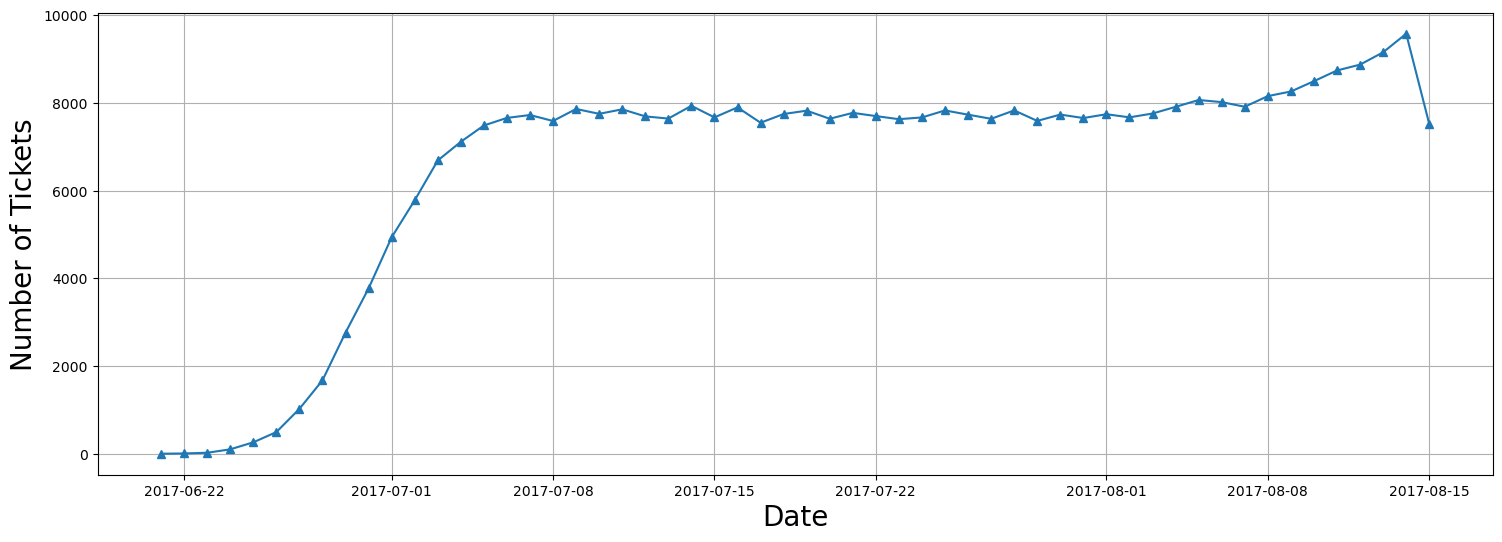

In [25]:
# 2. HOW MANY NUMBERS OF TICKETSBOOKED AND TOTAL AMOUNT EARNED CHANGED WITH THE TIME 

tickets = pd.read_sql_query("""select * from tickets inner join bookings
                  on tickets.book_ref = bookings.book_ref""" , connection)

# as book_date is in object type so we need to convert it into datetime so for that --->

tickets['book_date'] = pd.to_datetime(tickets['book_date'])
# to get dates  only we will create new column as date 
tickets['date'] = tickets['book_date'].dt.date
tickets
# NOW WE WILL CREATE A LINE CHART FOR INSIGHTS----->
x = tickets.groupby('date')[['date']].count()
plt.figure(figsize = (18,6))
plt.plot(x.index , x['date'] , marker = '^')
plt.xlabel('Date' , fontsize = 20)
plt.ylabel ('Number of Tickets' , fontsize = 20)
plt.grid('b')
plt.show()

In [26]:
 ## NOW FOR TOTAL AMOUNT EARNED PER DAY 

bookings = pd.read_sql_query("""select * from bookings""" , connection)
bookings['book_date'] = pd.to_datetime(bookings['book_date'])
bookings['date'] = bookings['book_date'].dt.date
bookings

,book_ref,book_date,total_amount,date
0,00000F,2017-07-05 03:12:00+03:00,265700,2017-07-05
1,000012,2017-07-14 09:02:00+03:00,37900,2017-07-14
2,000068,2017-08-15 14:27:00+03:00,18100,2017-08-15
3,000181,2017-08-10 13:28:00+03:00,131800,2017-08-10
4,0002D8,2017-08-07 21:40:00+03:00,23600,2017-08-07
...,...,...,...,...
262783,FFFEF3,2017-07-17 07:23:00+03:00,56000,2017-07-17
262784,FFFF2C,2017-08-08 05:55:00+03:00,10800,2017-08-08
262785,FFFF43,2017-07-20 20:42:00+03:00,78500,2017-07-20
262786,FFFFA8,2017-08-08 04:45:00+03:00,28800,2017-08-08


In [27]:
# now to get total amount earned per day

bookings.groupby('date')[['total_amount']].sum()

,total_amount
date,
2017-06-21,441900
2017-06-22,775300
2017-06-23,1822000
2017-06-24,5977000
2017-06-25,15305400
2017-06-26,29049100
2017-06-27,54339900
2017-06-28,91256400
2017-06-29,152484000


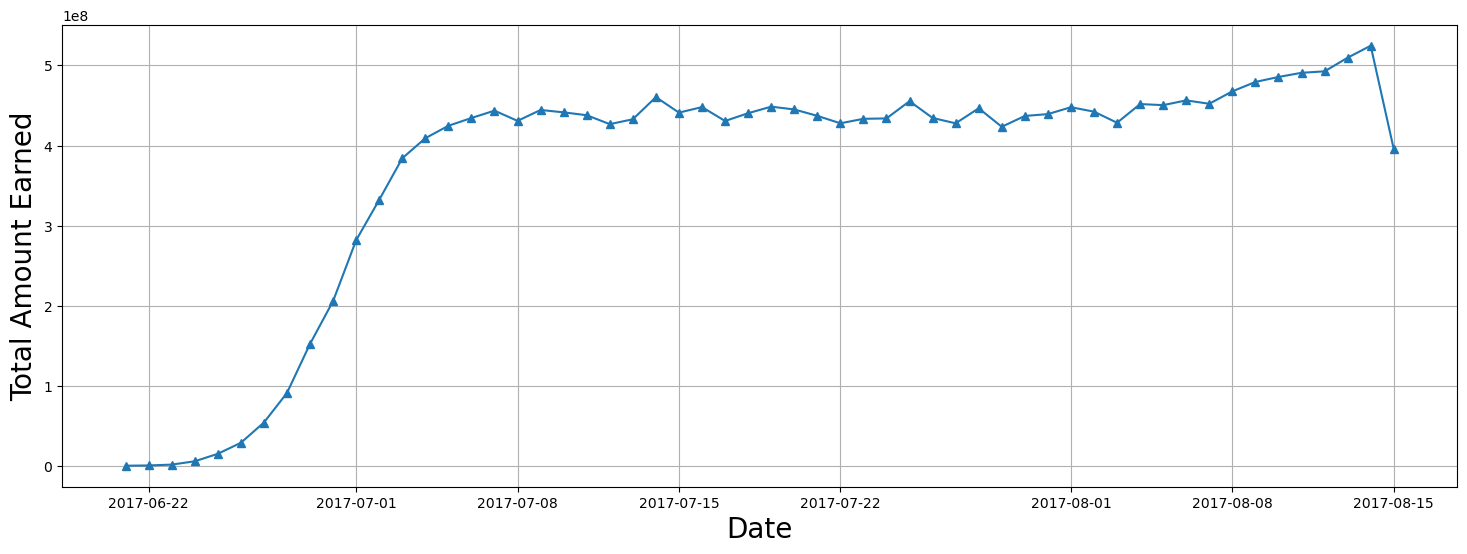

In [29]:
# lets make a line chart for total amount earned per day 

bookings = pd.read_sql_query("""select * from bookings""" , connection)
bookings['book_date'] = pd.to_datetime(bookings['book_date'])
bookings['date'] = bookings['book_date'].dt.date
x = bookings.groupby('date')[['total_amount']].sum()
plt.figure(figsize = (18,6))
plt.plot(x.index , x['total_amount'] , marker = '^')
plt.xlabel('Date' , fontsize = 20)
plt.ylabel ('Total Amount Earned' , fontsize = 20)
plt.grid('b')
plt.show()

In [31]:
# 3. NOW LETS CALCULATE THE AVERAGE CHARGE FOR EACH AIRCRAFT WITH DIFFERENT FARE CONDITIONS 

df = pd.read_sql_query("""select * from ticket_flights join flights
                        on ticket_flights.flight_id = flights.flight_id""" , connection)
df

,ticket_no,flight_id,fare_conditions,amount,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
0,0005432159776,30625,Business,42100,30625,PG0013,2017-07-16 18:15:00+03,2017-07-16 20:00:00+03,AER,SVO,Arrived,773,2017-07-16 18:18:00+03,2017-07-16 20:04:00+03
1,0005435212351,30625,Business,42100,30625,PG0013,2017-07-16 18:15:00+03,2017-07-16 20:00:00+03,AER,SVO,Arrived,773,2017-07-16 18:18:00+03,2017-07-16 20:04:00+03
2,0005435212386,30625,Business,42100,30625,PG0013,2017-07-16 18:15:00+03,2017-07-16 20:00:00+03,AER,SVO,Arrived,773,2017-07-16 18:18:00+03,2017-07-16 20:04:00+03
3,0005435212381,30625,Business,42100,30625,PG0013,2017-07-16 18:15:00+03,2017-07-16 20:00:00+03,AER,SVO,Arrived,773,2017-07-16 18:18:00+03,2017-07-16 20:04:00+03
4,0005432211370,30625,Business,42100,30625,PG0013,2017-07-16 18:15:00+03,2017-07-16 20:00:00+03,AER,SVO,Arrived,773,2017-07-16 18:18:00+03,2017-07-16 20:04:00+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045721,0005435097522,32094,Economy,5200,32094,PG0708,2017-09-14 17:15:00+03,2017-09-14 18:00:00+03,SGC,OVS,Scheduled,733,\N,\N
1045722,0005435097521,32094,Economy,5200,32094,PG0708,2017-09-14 17:15:00+03,2017-09-14 18:00:00+03,SGC,OVS,Scheduled,733,\N,\N
1045723,0005435104384,32094,Economy,5200,32094,PG0708,2017-09-14 17:15:00+03,2017-09-14 18:00:00+03,SGC,OVS,Scheduled,733,\N,\N
1045724,0005435104352,32094,Economy,5200,32094,PG0708,2017-09-14 17:15:00+03,2017-09-14 18:00:00+03,SGC,OVS,Scheduled,733,\N,\N


In [33]:
df = pd.read_sql_query("""select fare_conditions , aircraft_code , avg(amount) from ticket_flights join flights
                        on ticket_flights.flight_id = flights.flight_id
                        group by aircraft_code , fare_conditions""" , connection)
df

,fare_conditions,aircraft_code,avg(amount)
0,Business,319,113550.557703
1,Economy,319,38311.402347
2,Business,321,34435.662664
3,Economy,321,11534.974764
4,Business,733,41865.626175
5,Economy,733,13985.152000
6,Business,763,82839.842866
7,Economy,763,27594.721829
8,Business,773,57779.909435
9,Comfort,773,32740.552889


<Axes: xlabel='aircraft_code', ylabel='avg(amount)'>

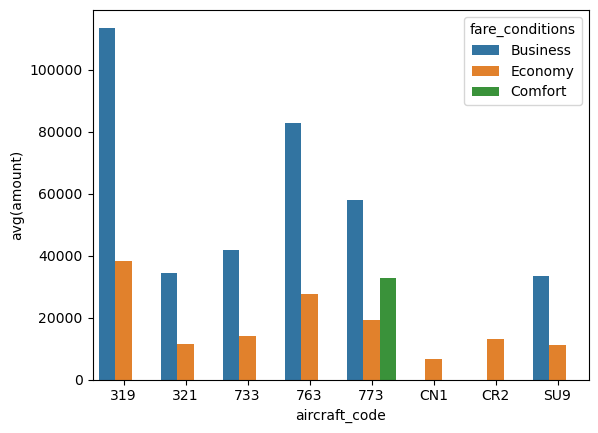

In [35]:
# plot a barchart for the above table to know about far_conditions with respect to amount and aircraft

sns.barplot(data = df , x = 'aircraft_code' , y = 'avg(amount)' , hue = 'fare_conditions')

NOW LETS DO THE ANALYSIS ON OCCUPANCY RATE ---->

In [39]:
## 1. FOR EACH AIRCRAFT CALCULATE THE TOTAL REVENUE PER YEAR AND THE AVERAGE REVENUE PER TICKET---->

pd.read_sql_query("""select aircraft_code , count(*) as ticket_count , sum(amount) as total_revenue from ticket_flights
                   join flights on ticket_flights.flight_id = flights.flight_id
                   group by aircraft_code""" , connection)

,aircraft_code,ticket_count,total_revenue
0,319,52853,2706163100
1,321,107129,1638164100
2,733,86102,1426552100
3,763,124774,4371277100
4,773,144376,3431205500
5,CN1,14672,96373800
6,CR2,150122,1982760500
7,SU9,365698,5114484700


In [44]:
# NOW CALCULATE TOTAL_REVENUE/TICKET COUNT ---->

pd.read_sql_query("""select aircraft_code, ticket_count, total_revenue, total_revenue/ticket_count as avg_revenue_per_ticket from(select aircraft_code , count(*) as ticket_count , sum(amount) as total_revenue from ticket_flights
                   join flights on ticket_flights.flight_id = flights.flight_id
                   group by aircraft_code)""" , connection)

,aircraft_code,ticket_count,total_revenue,avg_revenue_per_ticket
0,319,52853,2706163100,51201
1,321,107129,1638164100,15291
2,733,86102,1426552100,16568
3,763,124774,4371277100,35033
4,773,144376,3431205500,23765
5,CN1,14672,96373800,6568
6,CR2,150122,1982760500,13207
7,SU9,365698,5114484700,13985


In [61]:
## 2. NOW LETS CALCULATE THE AVERAGE OCCUPANCY PER AIRCRAFT---->

occupancy_rate = pd.read_sql_query("""select a.aircraft_code, avg(a.seats_count) as booked_seats, b.num_seats, avg(a.seats_count)/b.num_seats as occupancy_rate
from (select aircraft_code, flights.flight_id, count(*) as seats_count from boarding_passes
                  inner join flights
                  on boarding_passes.flight_id = flights.flight_id
                  group by aircraft_code , flights.flight_id) as a inner join
                  (select aircraft_code, count(*) as num_seats from seats group by aircraft_code ) as b
                  on a.aircraft_code = b.aircraft_code group by a.aircraft_code""" , connection
                  )
occupancy_rate

,aircraft_code,booked_seats,num_seats,occupancy_rate
0,319,53.583181,116,0.461924
1,321,88.809231,170,0.522407
2,733,80.255462,130,0.617350
3,763,113.937294,222,0.513231
4,773,264.925806,402,0.659019
5,CN1,6.004431,12,0.500369
6,CR2,21.482847,50,0.429657
7,SU9,56.812113,97,0.585692


In [62]:
## NOW LETS CALCULATE BY HOW MUCH THE TOTAL ANNUAL TURNOVER COULD INCREASE BY GIVING ALL AIRCRAFT A 10% HIGHER OCCUPANCY RATE 
occupancy_rate['Inc occupancy rate'] = occupancy_rate['occupancy_rate'] + occupancy_rate['occupancy_rate']*0.1
occupancy_rate

,aircraft_code,booked_seats,num_seats,occupancy_rate,Inc occupancy rate
0,319,53.583181,116,0.461924,0.508116
1,321,88.809231,170,0.522407,0.574648
2,733,80.255462,130,0.617350,0.679085
3,763,113.937294,222,0.513231,0.564554
4,773,264.925806,402,0.659019,0.724921
5,CN1,6.004431,12,0.500369,0.550406
6,CR2,21.482847,50,0.429657,0.472623
7,SU9,56.812113,97,0.585692,0.644261


In [63]:
# now we will calculate total revenue---->

total_revenue = pd.read_sql_query("""select aircraft_code, sum(amount) as total_revenue from ticket_flights
                join flights on ticket_flights.flight_id = flights.flight_id 
                group by aircraft_code""" , connection)
total_revenue

,aircraft_code,total_revenue
0,319,2706163100
1,321,1638164100
2,733,1426552100
3,763,4371277100
4,773,3431205500
5,CN1,96373800
6,CR2,1982760500
7,SU9,5114484700


In [67]:
pd.set_option("display.float_format" ,str)

In [68]:
total_revenue = pd.read_sql_query("""select aircraft_code, sum(amount) as total_revenue from ticket_flights
                join flights on ticket_flights.flight_id = flights.flight_id 
                group by aircraft_code""" , connection)
occupancy_rate['Inc Total Annual Turnover'] = (total_revenue['total_revenue']/occupancy_rate['occupancy_rate'])*occupancy_rate['Inc occupancy rate']
occupancy_rate

,aircraft_code,booked_seats,num_seats,occupancy_rate,Inc occupancy rate,Inc Total Annual Turnover
0,319,53.58318098720292,116,0.46192397402761143,0.5081163714303726,2976779410.0
1,321,88.80923076923077,170,0.5224072398190045,0.574647963800905,1801980510.0
2,733,80.25546218487395,130,0.617349709114415,0.6790846800258565,1569207310.0000002
3,763,113.93729372937294,222,0.5132310528350132,0.5645541581185146,4808404810.0
4,773,264.9258064516129,402,0.659019419033863,0.7249213609372492,3774326050.0
5,CN1,6.004431314623338,12,0.5003692762186115,0.5504062038404727,106011180.00000001
6,CR2,21.48284690220174,50,0.42965693804403476,0.4726226318484382,2181036550.0
7,SU9,56.81211267605634,97,0.5856918832583128,0.644261071584144,5625933169.999999
